In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
import seaborn as sns
import ast

In [2]:
df = pd.read_csv('valideringssett/labels.csv')
print(df.info())

df_2 = pd.read_csv('valideringssett/labels_2.csv')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1507 entries, 0 to 1506
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dokument_aar  1507 non-null   int64  
 1   dokument_nr   1507 non-null   int64  
 2   embete        1507 non-null   int64  
 3   sidetall      1507 non-null   int64  
 4   index         1507 non-null   int64  
 5   type          1507 non-null   object 
 6   height        1507 non-null   float64
 7   width         1507 non-null   float64
 8   x             1507 non-null   float64
 9   y             1507 non-null   float64
dtypes: float64(4), int64(5), object(1)
memory usage: 117.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1507 entries, 0 to 1506
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dokument_aar  1507 non-null   int64  
 1   dokument_nr   1507 non-null   int64  
 2   embete        1507 non-n

In [3]:
#Concatenate the two dataframes
df = pd.concat([df, df_2], axis=0)
print(df.head())
print(df.info())

   dokument_aar  dokument_nr  embete  sidetall  index          type  \
0          2017        52610     201         1      0  PERSONNUMMER   
1          1980        14847     101         1      0  PERSONNUMMER   
2          1980        14847     101         1      1  PERSONNUMMER   
3          1980         2377      31         1      0  PERSONNUMMER   
4          1980         2377      31         1      1  PERSONNUMMER   

      height      width           x           y ml_generated ml_status  
0  11.000000  29.500000  325.000000  211.500000          NaN       NaN  
1  17.223385  46.110317  534.443991  303.888723          NaN       NaN  
2  13.888889  43.333333  529.444444  408.888889          NaN       NaN  
3  15.000000  51.666667  339.444444  363.888889          NaN       NaN  
4  11.666667  37.222464  435.555192  292.777686          NaN       NaN  
<class 'pandas.core.frame.DataFrame'>
Index: 2572 entries, 0 to 1064
Data columns (total 12 columns):
 #   Column        Non-Null Count

In [4]:
#Change all negative values for width and height to positive
df['width'] = df['width'].abs()
df['height'] = df['height'].abs()

df["dokument_nr_embete"] = df["dokument_aar"].astype(str) + "_" + df["dokument_nr"].astype(str) + "_" + df["embete"].astype(str)


df.head()

,dokument_aar,dokument_nr,embete,sidetall,index,type,height,width,x,y,ml_generated,ml_status,dokument_nr_embete
0,2017,52610,201,1,0,PERSONNUMMER,11.000000,29.500000,325.000000,211.500000,NaN,NaN,2017_52610_201
1,1980,14847,101,1,0,PERSONNUMMER,17.223385,46.110317,534.443991,303.888723,NaN,NaN,1980_14847_101
2,1980,14847,101,1,1,PERSONNUMMER,13.888889,43.333333,529.444444,408.888889,NaN,NaN,1980_14847_101
3,1980,2377,31,1,0,PERSONNUMMER,15.000000,51.666667,339.444444,363.888889,NaN,NaN,1980_2377_31
4,1980,2377,31,1,1,PERSONNUMMER,11.666667,37.222464,435.555192,292.777686,NaN,NaN,1980_2377_31


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

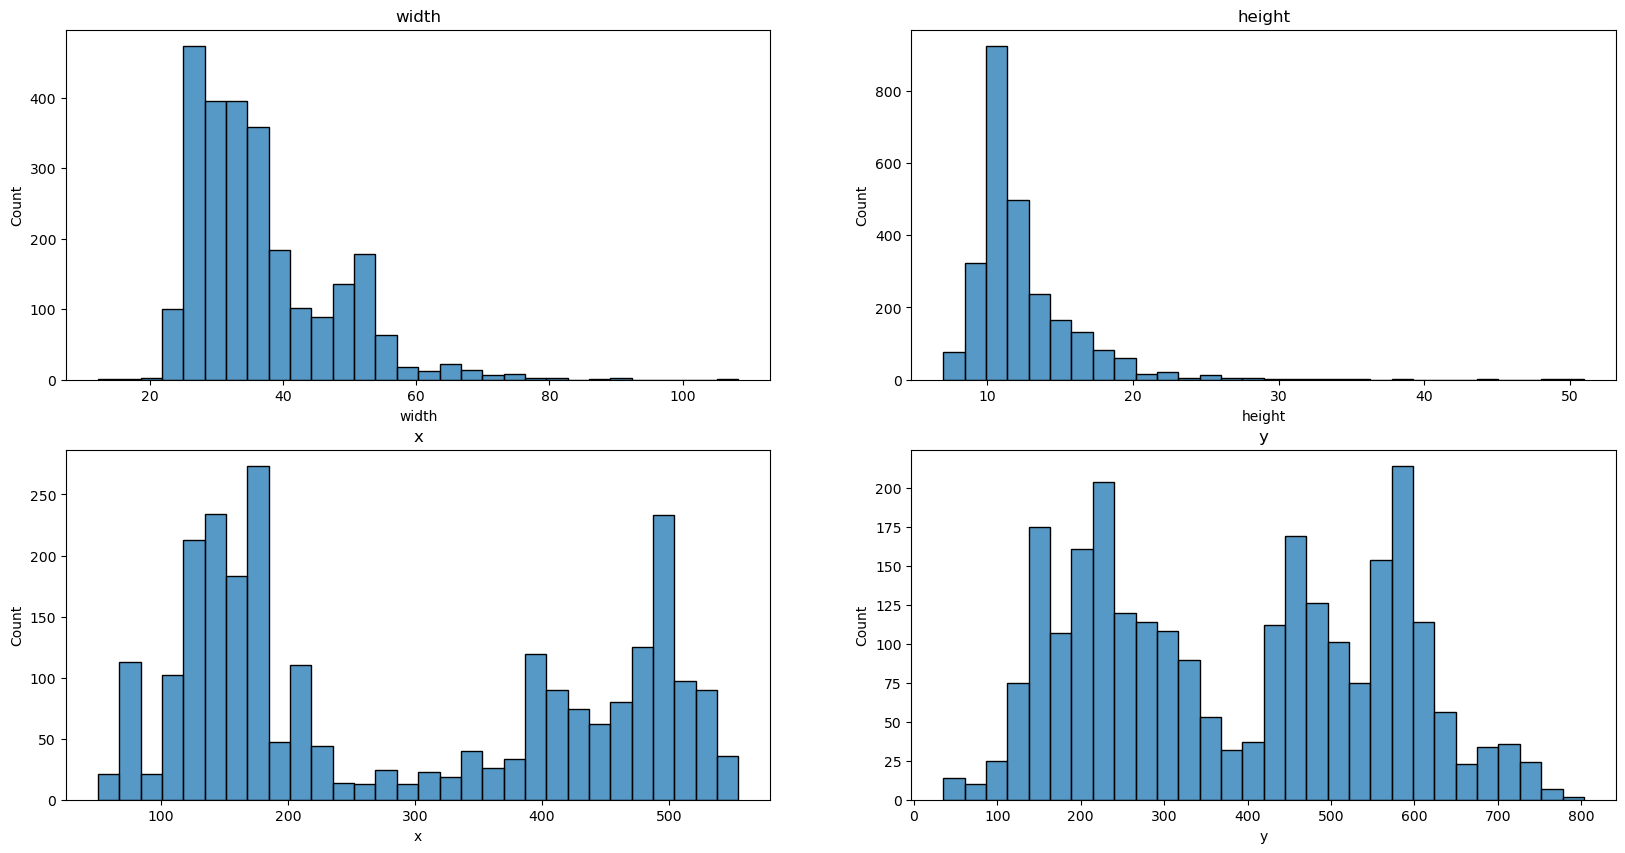

In [5]:
#Historgram of the width and height
#NB not normalized..

columns = ['width', 'height', 'x', 'y']

sx, fig = plt.subplots(2, 2, figsize=(20, 10))

for i, ax in enumerate(fig.flat):
    sns.histplot(df[columns[i]], ax=ax, bins=30)
    ax.set_title(columns[i])

plt.show()



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


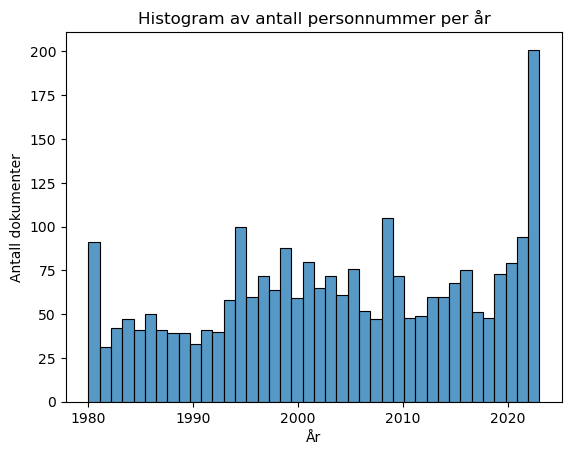

In [6]:
#Plot a histplot with the column 'aar' in df
sns.histplot(df['dokument_aar'], bins=40)
plt.title('Histogram av antall personnummer per år')
plt.ylabel('Antall dokumenter')
plt.xlabel('År')
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


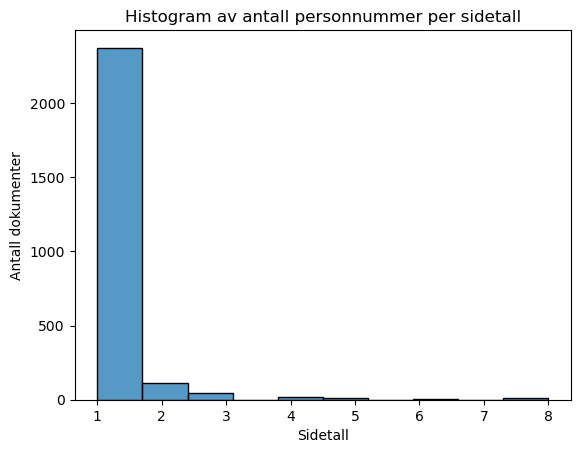

In [7]:
sns.histplot(df['sidetall'], bins=10)
plt.title('Histogram av antall personnummer per sidetall')
plt.ylabel('Antall dokumenter')
plt.xlabel('Sidetall')
plt.show()

In [8]:
df_dim = pd.read_csv('valideringssett/pdf_image_dimensions_all.csv')
df_dim.head()




,docid,pdf_dimensions,image_dimensions,ratio
0,1980_1349_50,"(597.1199951171875, 840.9600219726562)","(1659, 2336)","(0.3599276643262131, 0.3600000094061028)"
1,1980_1381_61,"(595.2000122070312, 841.6799926757812)","(1654, 2338)","(0.35985490459917246, 0.3599999968673145)"
2,1980_14847_101,"(595.4400024414062, 841.9199829101562)","(1654, 2339)","(0.3600000014760618, 0.3599486887174674)"
3,1980_174_23,"(596.1599731445312, 845.280029296875)","(1656, 2349)","(0.3599999837829295, 0.35984675576708175)"
4,1980_2377_31,"(597.3599853515625, 842.6400146484375)","(1660, 2341)","(0.35985541286238704, 0.35994874611210487)"


In [9]:
#Convert 'pdf_dimensions' column to a tuple
df_dim['pdf_dimensions'] = df_dim['pdf_dimensions'].apply(lambda x: tuple(ast.literal_eval(x)))
df_dim['image_dimensions'] = df_dim['image_dimensions'].apply(lambda x: tuple(ast.literal_eval(x)))


df_dim['pdf_width'] = df_dim['pdf_dimensions'].apply(lambda x: x[0])
df_dim['pdf_height'] = df_dim['pdf_dimensions'].apply(lambda x: x[1])


df_dim['image_width'] = df_dim['image_dimensions'].apply(lambda x: x[0])
df_dim['image_height'] = df_dim['image_dimensions'].apply(lambda x: x[1])

df_dim.drop(['pdf_dimensions', 'image_dimensions', 'ratio'], axis=1, inplace=True)

df_dim.head()


,docid,pdf_width,pdf_height,image_width,image_height
0,1980_1349_50,597.119995,840.960022,1659,2336
1,1980_1381_61,595.200012,841.679993,1654,2338
2,1980_14847_101,595.440002,841.919983,1654,2339
3,1980_174_23,596.159973,845.280029,1656,2349
4,1980_2377_31,597.359985,842.640015,1660,2341


In [10]:
merged_df = df.merge(df_dim, left_on='dokument_nr_embete', right_on='docid')

# Calculate the normalized dimensions
merged_df['normalized_width'] = merged_df['width'] / merged_df['pdf_width']
merged_df['normalized_height'] = merged_df['height'] / merged_df['pdf_height']
merged_df['normalized_x'] = merged_df['x'] / merged_df['pdf_width']
merged_df['normalized_y'] = merged_df['y'] / merged_df['pdf_height']

# Drop the columns from df_dim if not needed
result_df = merged_df.drop(columns=['pdf_width', 'pdf_height', 'docid'])

# Print or save the result
result_df.head()

,dokument_aar,dokument_nr,embete,sidetall,index,type,height,width,x,y,ml_generated,ml_status,dokument_nr_embete,image_width,image_height,normalized_width,normalized_height,normalized_x,normalized_y
0,2017,52610,201,1,0,PERSONNUMMER,11.000000,29.500000,325.000000,211.500000,NaN,NaN,2017_52610_201,1654,2338,0.049563,0.013069,0.546035,0.251283
1,1980,14847,101,1,0,PERSONNUMMER,17.223385,46.110317,534.443991,303.888723,NaN,NaN,1980_14847_101,1654,2339,0.077439,0.020457,0.897561,0.360947
2,1980,14847,101,1,1,PERSONNUMMER,13.888889,43.333333,529.444444,408.888889,NaN,NaN,1980_14847_101,1654,2339,0.072775,0.016497,0.889165,0.485662
3,1980,2377,31,1,0,PERSONNUMMER,15.000000,51.666667,339.444444,363.888889,NaN,NaN,1980_2377_31,1660,2341,0.086492,0.017801,0.568241,0.431844
4,1980,2377,31,1,1,PERSONNUMMER,11.666667,37.222464,435.555192,292.777686,NaN,NaN,1980_2377_31,1660,2341,0.062312,0.013845,0.729134,0.347453


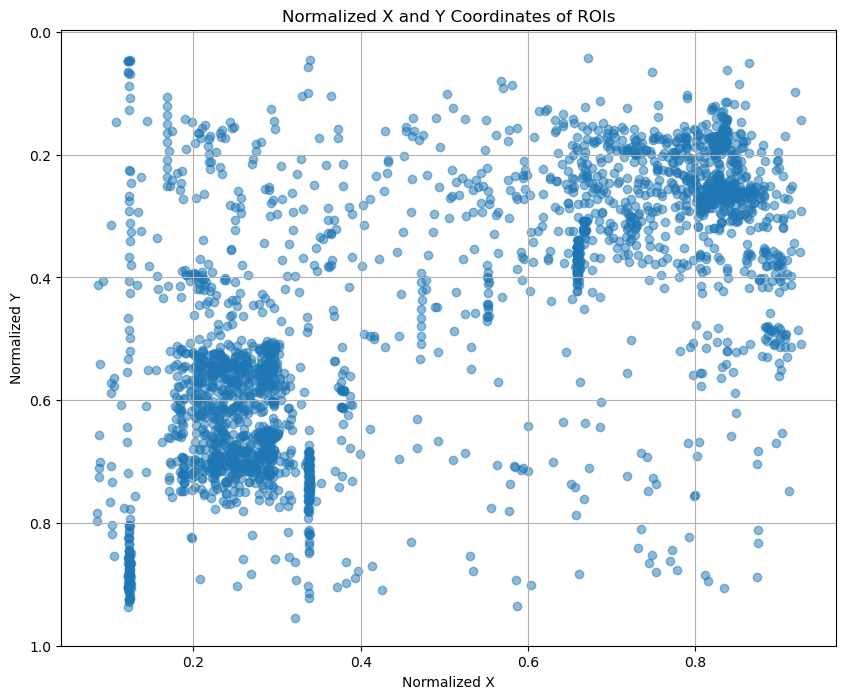

In [11]:
plt.figure(figsize=(10, 8))
plt.scatter(result_df['normalized_x'], result_df['normalized_y'], alpha=0.5)
plt.title('Normalized X and Y Coordinates of ROIs')
plt.xlabel('Normalized X')
plt.ylabel('Normalized Y')
plt.gca().invert_yaxis()  # Invert the y-axis to have the origin at the top-left
plt.grid(True)
plt.show()

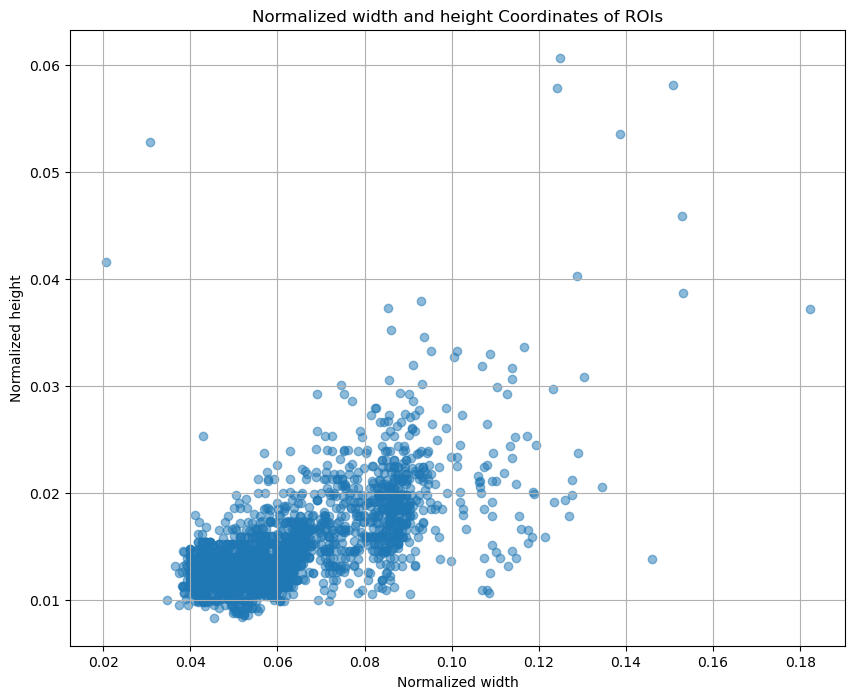

In [12]:
plt.figure(figsize=(10, 8))
plt.scatter(result_df['normalized_width'], result_df['normalized_height'], alpha=0.5)
plt.title('Normalized width and height Coordinates of ROIs')
plt.xlabel('Normalized width')
plt.ylabel('Normalized height')
plt.grid(True)
plt.show()

In [13]:
print(len(df))
print(len(df_dim))

2572
1335
